 # PROJET IA - **MODELISATION**

## Introduction



A l'heure où l'intelligence artificielle (IA) explose et devient la 4e grande révolution technologique, nous sommes constamment exposés au challenge énergétique qui en découle. Cependant, l'aspect matériel est quant à lui très peu souvent abordé. Cette étude a pour but de mettre le doigt sur les consommations en matériaux pour soutenir la demande de l'IA.



L'objectif est de modéliser la demande en matériaux nécessaires au bon fonctionnement de l'IA générative dans un futur proche. L'IA de référence est chatGPT 4 (autour de 17 500 milliards de paramètres). Il est important de noter que les résultats concernent uniquement les besoins matériaux pour le fonctionnement des unités GPU. Les composants d'infrastructure plus larges, tels que les réseaux, le stockage et les systèmes de refroidissement, ne sont pas pris en compte dans cette analyse.

La puce GPU étudiée est la NVIDIA A100, utilisé par OpenAI, Meta, Microsoft.
Le modèle ChatGPT 4 sera donc la référence dans les calculs, en faisant ensuite l'hypothèse que la consommation en matériaux des autres IA génératives est similaire.


Dans une première partie, nous verrons la modèlisation des besoins matériaux relatif à la demande en IA.
Dans une seconde partie, nous analyserons le résultat de l'analyse au vu des ressources actuelles en matériaux, tout en prenant en compte les facteurs géographiques, géopolitiques et commerciales.

Une grande partie des données de référence proviennent d'une source, qui est la suivante : [1] *From FLOPs to Footprints: The Resource Cost of Artificial Intelligence* ; Sophia Falk, Nicholas Kluge Correa, Sasha Luccioni, Lisa Biber-Freudenberger, and Aimee van Wynsberghe ; 3 Décembre 2025.

Nous avons fait le choix de commencer le modèle en partant des requêtes. Ces requêtes ne sont autres que des chaînes de caractères découpés en tokens. Ces tokens sont traités dans les data centers par des FLOPS (number of floating-point operations it can perform per second). Ainsi, il suffit de faire le lien entre requêtes et nombre de calculs associés (FLOPs) pour pouvoir remonter au nombre de GPUs nécessaires. Avec cette quantité, nous retrouvons la demande en matériaux associée.


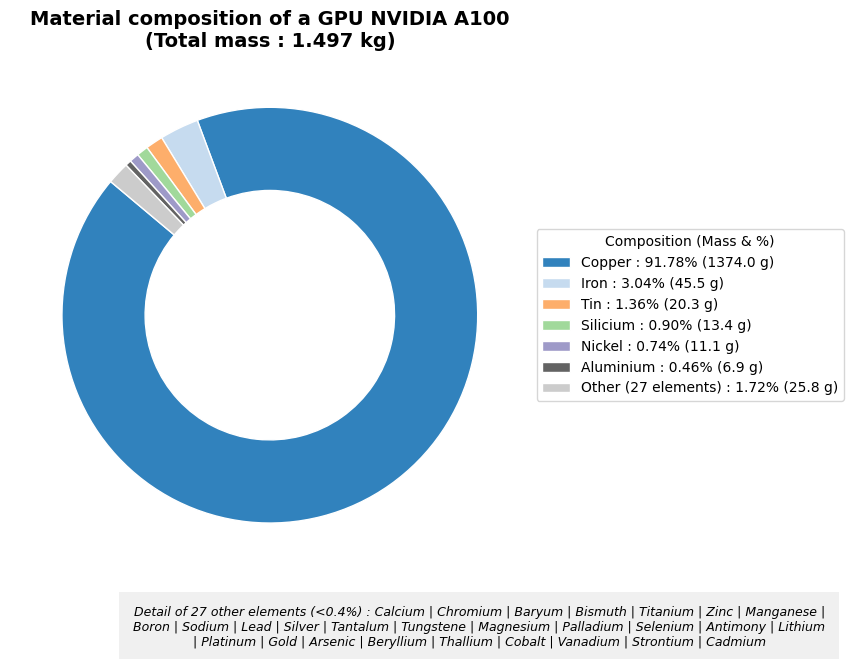

In [ ]:
import matplotlib.pyplot as plt
import textwrap
import numpy as np

# --- 1. Les Données ---
gpu_A100 = {
    # --- 1. MATÉRIAUX MAJEURS (> 10g) ---
    "Copper": 1.374,
    "Iron": 0.0455,
    "Tin": 0.0203,
    "Silicium": 0.0134,
    "Nickel": 0.0111,
    "Aluminium": 0.0069,
    "Baryum": 0.00405,
    "Calcium": 0.00578,
    "Chromium": 0.00525,

    # --- 2. MÉTAUX PRÉCIEUX & CRITIQUES ---
    "Silver": 0.000553,
    "Gold": 0.0000426,
    "Palladium": 0.00020,
    "Platinum": 0.0000565,
    "Cobalt": 0.0000165,
    "Lithium": 0.0000731,
    "Tantalum": 0.00041,
    "Tungstene": 0.00035,

    # --- 3. AUTRES MÉTAUX & TOXIQUES ---
    "Zinc": 0.00118,
    "Bismuth": 0.0028,
    "Magnesium": 0.000311,
    "Manganese": 0.000918,
    "Lead": 0.000656,
    "Titanium": 0.0014,
    "Boron": 0.000782,
    "Sodium": 0.000691,
    "Arsenic": 0.0000335,
    "Antimony": 0.000085,
    "Selenium": 0.0000937,
    "Thallium": 0.0000228,
    "Vanadium": 0.0000122,
    "Beryllium": 0.0000238,
    "Cadmium": 0.00000443,
    "Strontium": 0.0000054
}

def plot_gpu_composition_clean(data_dict):
    # --- 1. Préparation des Données ---
    # Calcul de la masse totale pour faire des %
    total_mass = sum(data_dict.values())

    # Tri décroissant
    sorted_items = sorted(data_dict.items(), key=lambda item: item[1], reverse=True)

    # Séparation intelligente : On garde ceux > 0.4% de la masse totale
    # Sinon ils sont invisibles sur le graphique
    threshold_pct = 0.004 # 0.4%

    main_slices = []
    others_slices = []

    for name, mass in sorted_items:
        if mass / total_mass >= threshold_pct:
            main_slices.append((name, mass))
        else:
            others_slices.append((name, mass))

    # Préparation pour le plot
    labels = [item[0] for item in main_slices]
    sizes = [item[1] for item in main_slices]

    # Gestion du groupe "Autres"
    others_mass = sum(item[1] for item in others_slices)
    others_count = len(others_slices)

    labels.append(f"Other ({others_count} elements)")
    sizes.append(others_mass)

    # --- 2. Création du Graphique ---
    fig, ax = plt.subplots(figsize=(12, 7)) # Format plus large pour la légende

    # Palette de couleurs pro
    colors = plt.cm.tab20c(np.linspace(0, 1, len(sizes)))
    # On met le Cuivre en couleur distincte (le premier) et "Autres" en gris
    colors[-1] = (0.8, 0.8, 0.8, 1.0) # Gris pour "Autres"

    # Le Donut
    wedges, texts = ax.pie(sizes,
                           startangle=140,
                           colors=colors,
                           wedgeprops=dict(width=0.4, edgecolor='w')) # Donut ring

    # --- 3. Légende Intelligente (au lieu des étiquettes superposées) ---
    # On construit les labels de la légende avec les % exacts
    legend_labels = []
    for i, mass in enumerate(sizes):
        pct = (mass / total_mass) * 100
        label_text = f"{labels[i]} : {pct:.2f}% ({mass*1000:.1f} g)"
        legend_labels.append(label_text)

    # Placement de la légende sur le côté droit
    ax.legend(wedges, legend_labels,
              title="Composition (Mass & %)",
              loc="center left",
              bbox_to_anchor=(1, 0, 0.5, 1), # À l'extérieur du graphe
              fontsize=10)

    ax.set_title(f"Material composition of a GPU NVIDIA A100\n(Total mass : {total_mass:.3f} kg)",
                 fontsize=14, fontweight='bold')

    # --- 4. Texte de détail pour les traces (Le 'Footnote') ---
    # Liste des matériaux dans "Autres"
    others_names = [item[0] for item in others_slices]
    others_text_raw = " | ".join(others_names)
    wrapped_text = "\n".join(textwrap.wrap(f"Detail of {others_count} other elements (<0.4%) :\n" + others_text_raw, width=110))

    plt.figtext(0.5, 0.02, wrapped_text, ha="center", fontsize=9, style='italic',
                bbox={"facecolor":"#f0f0f0", "edgecolor":"none", "pad":10})

    plt.tight_layout(rect=[0, 0.1, 0.75, 0.95]) # Ajustement pour laisser la place à la légende et au texte
    plt.show()

plot_gpu_composition_clean(gpu_A100)

# I. Modélisation de la demande en matériaux lié aux requêtes utilisateurs

Pour ce modèle, nous considérerons 3 scénarios:

*   La performance des GPUs est constante.
*   Evolution optimiste de la performance des GPUs.
*   Evolution pessimiste de la performance des GPUs.





## Modélisation du nombre GPUs nécessaires

Code calculant le nombre de GPU nécessaire en prenant en argument le nombre de requêtes sur une période donnée.

Performance de la puce A100 = $312 TFLOPS$
Ce chiffre correspond à la performance théorique maximale de la puce Nvidia A100 en précision BF16 (Brain Float 16).
MFU = 0,35 % selon [1]


Hypothèses :

*   Les GPUs ont une durée de vie d'une année et demi.
*   Nombre de FLOPs pour l'entraînement = $6 * N_active * D_train$
*   Nombre de FLOP pour une requête = $2 * Paramètres actifs du modèle * Nombre de tokens$
*   Toutes les requêtes sont équivalentes à une requête moyenne qui fait 1000 tokens (750 mots).

Selon le scénario SemiAnalysis retenu par le document:
Le modèle a 1.76T paramètres au total, mais seulement 222B actifs par passe.


Nombre de FLOP par requête = 5e14 FLOP

*   En ce qui concerne la croissance du nombre de requête chaque année, une étude de McKinsey considère que ce nombre augmente de 33% chaque année pendant 10 ans. Nous estimerons dans cette étude, que cette valeur suit une croissance agressive et ainsi double chaque année pendant 5 ans (en effet, seulement 10% de la population adulte utilise l'IA générative en 2024 selon [1]), puis connaît un ralentissement lié à la saturation de l'usage humain et augmente donc de 33% sur les 5 dernières années.

In [ ]:
FLOPS_per_request= 1e15

def compute_gpu(
    N_requests_per_year,
    C,
    lifespan_years=1.5,
    MFU=0.35
    ):
    """
    Calcule le nombre de GPUs A100 nécessaires spécifiquement pour GPT-4.
    Intègre le coût de l'entraînement ET de l'inférence (utilisation).

    Basé sur les données du papier 'From FLOPs to Footprints'.
    """

    # 1. CONSTANTES MATÉRIELLES
    perf_peak_flops = C
    seconds_per_year = 365 * 24 * 3600

    # Capacité théorique annuelle d'un GPU (si 100% utilisé 24h/24)
    capacity_per_gpu_theoretical = perf_peak_flops * seconds_per_year

    # Capacité RÉELLE (Effective) après ajustement MFU (Model FLOPs Utilization)
    capacity_per_gpu_effective = capacity_per_gpu_theoretical * MFU

    # 2. CARACTÉRISTIQUES GPT-4
    N_active_params = 222e9   # 222 Milliards (Paramètres Actifs)
    D_training_tokens = 13e12 # 13 Trillions (Dataset d'entraînement)

    # 3. CALCUL DE LA DEMANDE EN FLOPs

    # A. Coût de l'Entraînement (Training)

    annual_flops_training = 6 * N_active_params * D_training_tokens

    # B. Coût de l'Utilisation (Inférence)

    # Formule Inférence MoE : 2 * N_active * N_requetes * Tokens/req

    annual_flops_inference = FLOPS_per_request * N_requests_per_year

    # C. Demande Totale Annuelle (FLOPs)
    total_annual_flops = annual_flops_training + annual_flops_inference

    # 4. CALCUL DES GPUs

    # Formule : Demande Totale / (Capacité Effective d'un GPU x Durée de vie d'une puce)
    gpu_consumption_annual = total_annual_flops / (capacity_per_gpu_effective*lifespan_years)

    return gpu_consumption_annual


print(compute_gpu(N_requests_per_year = 4e11,
    C = 312e12,
    lifespan_years=2,
    MFU=0.35))

60590.67560209113


Fonction Visualize pour observer les tendances en matériaux

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick # Pour le formatage en %
import numpy as np
import math

# --- 1. Données de référence (Production Mondiale 2023/2024 en kg) ---
production_mondiale = {
    "Copper": 22e9,         # 22 Millions tonnes
    "Iron": 1.5e12,          # 1.5 Milliard tonnes (Fonte)
    "Tin": 300e6,         # 300 000 tonnes
    "Silicium": 9e9,        # 9 Millions tonnes (Métal)
    "Nickel": 3.6e9,        # 3.6 Millions tonnes
    "Aluminium": 70e9,      # 70 Millions tonnes
    "Baryum": 8e9,          # 8 Millions tonnes
    "Calcium": 1e11,        # ~100 Millions tonnes (Abondant)
    "Chromium": 41e9,         # 41 Millions tonnes

    "Silver": 26e6,         # 26 000 tonnes
    "Gold": 3e6,              # 3 000 tonnes
    "Palladium": 210e3,     # 210 tonnes
    "Platinum": 180e3,       # 180 tonnes
    "Cobalt": 230e6,        # 230 000 tonnes
    "Lithium": 180e6,       # 180 000 tonnes
    "Tantalum": 2e6,         # 2 000 tonnes
    "Tungstene": 78e6,      # 78 000 tonnes

    "Zinc": 12e9,           # 12 Millions tonnes
    "Bismuth": 20e6,        # 20 000 tonnes
    "Magnesium": 1e9,       # 1 Million tonnes
    "Manganese": 20e9,      # 20 Millions tonnes
    "Lead": 4.5e9,         # 4.5 Millions tonnes
    "Titanium": 260e6,        # 260 000 tonnes (Éponge métal)
    "Boron": 2.5e9,          # 2.5 Millions tonnes
    "Sodium": 300e9,        # 300 Millions tonnes
    "Arsenic": 50e6,        # 50 000 tonnes
    "Antimony": 83e6,      # 83 000 tonnes
    "Selenium": 3e6,        # 3 000 tonnes
    "Thallium": 8e3,        # 8 tonnes (ATTENTION : TRÈS FAIBLE)
    "Vanadium": 100e6,      # 100 000 tonnes
    "Beryllium": 340e3,     # 340 tonnes
    "Cadmium": 24e6,        # 24 000 tonnes
    "Strontium": 300e6      # 300 000 tonnes
}



def visualize_impact(projection, production_ref):
    """
    Affiche les courbes avec deux axes Y en ÉCHELLE LINÉAIRE.
    Prend directement les valeurs en entrée (supposées être en kg).
    """
    if not projection:
        print("Missing data.")
        return

    # Préparation des données X
    annees = np.array([p["annee"] for p in projection]) + 2025

    keys = list(projection[0]["materiaux_totaux"].keys())
    n_plots = len(keys)
    cols = 5
    rows = math.ceil(n_plots / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4 * rows))
    fig.suptitle(f"AI material needs vs World production ({annees[0]}-{annees[-1]})", fontsize=16, y=0.98)

    axes_flat = axes.flatten() if n_plots > 1 else [axes]

    for i, key in enumerate(keys):
        ax1 = axes_flat[i]

        # --- Données brutes (Supposées en kg) ---
        y_values_kg = [p["materiaux_totaux"][key] for p in projection]

        # --- AXE GAUCHE : MASSE (kg) ---
        ax1.plot(annees, y_values_kg, marker='o', linestyle='-', linewidth=2, color='tab:blue', label="Masse requise")

        ax1.set_title(key, fontsize=12, fontweight='bold')
        ax1.set_ylabel("Cumulated mass (kg)", color='tab:blue', fontsize=9)
        ax1.tick_params(axis='y', labelcolor='tab:blue')
        ax1.grid(True, linestyle='-', alpha=0.3)

        # Force le démarrage à 0 pour lisibilité
        ax1.set_ylim(bottom=0)

        # --- AXE DROIT : % PRODUCTION MONDIALE ---
        prod_annuelle_kg = production_ref.get(key, None)

        if prod_annuelle_kg:
            ax2 = ax1.twinx()

            # Récupérer les limites de l'axe de gauche
            y1_min, y1_max = ax1.get_ylim()

            # Calcul des % (Masse_IA / Prod_Monde * 100)
            pct_min = (y1_min / prod_annuelle_kg) * 100
            pct_max = (y1_max / prod_annuelle_kg) * 100

            ax2.set_ylim(pct_min, pct_max)
            ax2.set_ylabel("% World Prod.", color='tab:red', fontsize=9, fontweight='bold')
            ax2.tick_params(axis='y', labelcolor='tab:red')

            # Formatage %
            ax2.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=2))

            # Lignes d'alerte (Rouge si > 1% ou 5%)
            # On affiche les seuils seulement s'ils sont pertinents pour l'échelle
            if pct_max >= 1.0:
                ax2.axhline(y=1.0, color='red', linestyle=':', alpha=0.5, linewidth=1, label="Seuil 1%")
            if pct_max >= 5.0:
                ax2.axhline(y=5.0, color='darkred', linestyle='--', alpha=0.5, linewidth=1, label="Seuil 5%")
            if pct_max >= 100.0: # Alerte critique si on dépasse la prod mondiale
                 ax2.axhline(y=100.0, color='black', linestyle='-', linewidth=1.5, label="100% Prod")

    # Masquer les graphiques vides
    for j in range(i + 1, len(axes_flat)):
        fig.delaxes(axes_flat[j])

    plt.tight_layout(rect=[0, 0.03, 1, 0.96])
    plt.show()


# Fonction pour visualiser deux projections sur un meme grpahe

def visualize_impact_comparison(proj1, proj2, production_ref):
    """
    Affiche deux scénarios sur les mêmes graphiques pour comparaison.

    Args:
        proj1: Liste résultats scénario 1 (Performance Constante)
        proj2: Liste résultats scénario 2 (Optimiste / Loi de Moore)
        production_ref: Dictionnaire production mondiale (kg)
    """
    if not proj1 or not proj2:
        print("Missing data")
        return

    # Préparation des données X (Années)
    annees = np.array([p["annee"] for p in proj1]) + 2025

    # Récupération des clés
    keys = list(proj1[0]["materiaux_totaux"].keys())
    n_plots = len(keys)
    cols = 3
    rows = math.ceil(n_plots / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))

    # Titre global du graphique
    fig.suptitle(f"Comparison of material needs ({annees[0]}-{annees[-1]})", fontsize=16, y=0.98)

    axes_flat = axes.flatten() if n_plots > 1 else [axes]

    for i, key in enumerate(keys):
        ax1 = axes_flat[i]

        # --- Récupération des données (kg) ---
        y1 = [p["materiaux_totaux"][key] for p in proj1]
        y2 = [p["materiaux_totaux"][key] for p in proj2]

        # --- AXE GAUCHE : MASSE (kg) ---

        # Courbe 1 : Performance Constante (Bleu plein)
        l1 = ax1.plot(annees, y1, color='tab:blue', linestyle='-', linewidth=2,
                      label="Constant performance projection")

        # Courbe 2 : Optimiste (Orange pointillé)
        l2 = ax1.plot(annees, y2, color='tab:orange', linestyle='--', linewidth=2,
                      label="Optimistic projection")

        ax1.set_title(key, fontsize=12, fontweight='bold')
        ax1.set_ylabel("Cumulated mass (kg)", fontsize=9)
        ax1.grid(True, linestyle='-', alpha=0.3)

        # Calcul du maximum global pour ajuster l'échelle pour que tout rentre
        max_val = max(max(y1), max(y2))
        if max_val > 0:
            ax1.set_ylim(bottom=0, top=max_val * 1.2) # Marge de 20% en haut

        # --- Légende ---
        # On ne l'affiche que sur le premier graphique pour ne pas surcharger,
        # ou sur tous si tu préfères. Ici : sur tous, mais en petit.
        ax1.legend(fontsize=8, loc='upper left')

        # --- AXE DROIT : % PRODUCTION MONDIALE ---
        prod_annuelle_kg = production_ref.get(key, None)

        if prod_annuelle_kg:
            ax2 = ax1.twinx()

            # Récupérer les limites de l'axe de gauche
            y1_min, y1_max = ax1.get_ylim()

            # Calcul des % correspondants
            pct_min = (y1_min / prod_annuelle_kg) * 100
            pct_max = (y1_max / prod_annuelle_kg) * 100

            ax2.set_ylim(pct_min, pct_max)
            ax2.set_ylabel("% World Prod.", color='tab:red', fontsize=9, fontweight='bold')
            ax2.tick_params(axis='y', labelcolor='tab:red')

            # Formatage %
            ax2.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=1))

            # --- LIGNES D'ALERTE ---
            if pct_max >= 1.0:
                ax2.axhline(y=1.0, color='red', linestyle=':', alpha=0.6, linewidth=1, label="1%")
            if pct_max >= 5.0:
                ax2.axhline(y=5.0, color='darkred', linestyle='-.', alpha=0.6, linewidth=1, label="5%")
            if pct_max >= 20.0:
                 ax2.axhline(y=20.0, color='purple', linestyle='--', alpha=0.6, linewidth=1, label="20%")
            if pct_max >= 100.0:
                 ax2.axhline(y=100.0, color='black', linestyle='-', linewidth=1.5, label="100%")

    # Masquer les graphiques vides
    for j in range(i + 1, len(axes_flat)):
        fig.delaxes(axes_flat[j])

    plt.tight_layout(rect=[0, 0.03, 1, 0.96])
    plt.show()


## Modélisation et prévision des quantités nécessaires en matériaux

In [ ]:
# Données


# Capacité d'une puce NVIDIA H100 en TFLOPS (source : [1] ; valeur exacte et certifiée pour la performance en BF16 (Brain Float 16) de la NVIDIA A100
C0 = 312e12

# Vecteur Matériau ; toutes les masses sont en kg
gpu_A100 = {
    # --- 1. MATÉRIAUX MAJEURS (> 10g) ---
    "Copper": 1.374,
    "Iron": 0.0455,
    "Tin": 0.0203,
    "Silicium": 0.0134,
    "Nickel": 0.0111,
    "Aluminium": 0.0069,
    "Baryum": 0.00405,
    "Calcium": 0.00578,
    "Chromium": 0.00525,

    # --- 2. MÉTAUX PRÉCIEUX & CRITIQUES ---
    "Silver": 0.000553,
    "Gold": 0.0000426,
    "Palladium": 0.00020,
    "Platinum": 0.0000565,
    "Cobalt": 0.0000165,
    "Lithium": 0.0000731,
    "Tantalum": 0.00041,
    "Tungstene": 0.00035,

    # --- 3. AUTRES MÉTAUX & TOXIQUES ---
    "Zinc": 0.00118,
    "Bismuth": 0.0028,
    "Magnesium": 0.000311,
    "Manganese": 0.000918,
    "Lead": 0.000656,
    "Titanium": 0.0014,
    "Boron": 0.000782,
    "Sodium": 0.000691,
    "Arsenic": 0.0000335,
    "Antimony": 0.000085,
    "Selenium": 0.0000937,
    "Thallium": 0.0000228,
    "Vanadium": 0.0000122,
    "Beryllium": 0.0000238,
    "Cadmium": 0.00000443,
    "Strontium": 0.0000054
}

# Vecteur nombre de requêtes par an sur 10 ans (calculé précédemment)
# Croissance "Hyper-Croissance" (x2/an) puis alignement marché
R = {
    "a_0": 4.5e11,   # ~1 milliard de requêtes/jour (Niveau Google Search/ChatGPT)
    "a_1": 9.0e11,   # x2
    "a_2": 1.8e12,   # x2
    "a_3": 3.6e12,   # x2
    "a_4": 7.2e12,   # x2
    "a_5": 1.4e13,   # x2
    "a_6": 2.5e13,   # Ralentissement (saturation usage humain) ; coefficient de 1,33
    "a_7": 4.0e13,
    "a_8": 6.0e13,
    "a_9": 8.5e13,
    "a_10": 1.1e14   # Arrivée à ~100 Tera-requêtes
}


FLOPS_per_request= 1e15

In [ ]:
def Projection_Perf_cons(n,C,Req):

    key = f"a_{n}"
    N_req_annee_n = Req[key]

    n_gpu = compute_gpu(N_requests_per_year = N_req_annee_n,C = C,lifespan_years=3,MFU=0.35)

    materiaux_totaux = {key : 0 for key in gpu_A100.keys()}

    for key in gpu_A100.keys():
        materiaux_totaux[key] += gpu_A100[key]*n_gpu

    return{
        "annee": n,
        "n_gpu": n_gpu,
        "materiaux_totaux": materiaux_totaux
    }

Hypothèses :    


*   Evolution des capacités des GPUs suivent une loi de Moore et doublent chaque année




In [ ]:
def Projection_Perf_Realiste(n, C, Req):
    """
    Projection basée sur une Loi de Moore réaliste pour l'IA :
    Doublement de la performance des puces tous les 2 ans (CAGR ~41%).

    Cela correspond à l'historique V100 -> A100 (x3 en 3 ans) cité dans le document.
    """
    key = f"a_{n}"
    if key not in Req:
        return f"Erreur : Année {key} introuvable dans R"

    N_req_annee_n = Req[key]

    # on utilise 2**(n/2) (doubling every 2 years)
    growth_factor = 2 ** (n / 2.0)
    C_future = C0 * growth_factor

    # Calcul du nombre de GPU avec cette nouvelle capacité
    n_gpu = compute_gpu(
        N_requests_per_year=N_req_annee_n,
        C=C_future,
        lifespan_years=3,
        MFU=0.35
    )

    # Calcul des matériaux (Composition Constante par GPU)
    materiaux_totaux = {}
    for mat, qte_unitaire in gpu_A100.items():
        materiaux_totaux[mat] = qte_unitaire * n_gpu

    return {
        "annee": n,
        "n_gpu": n_gpu,
        "materiaux_totaux": materiaux_totaux,
    }

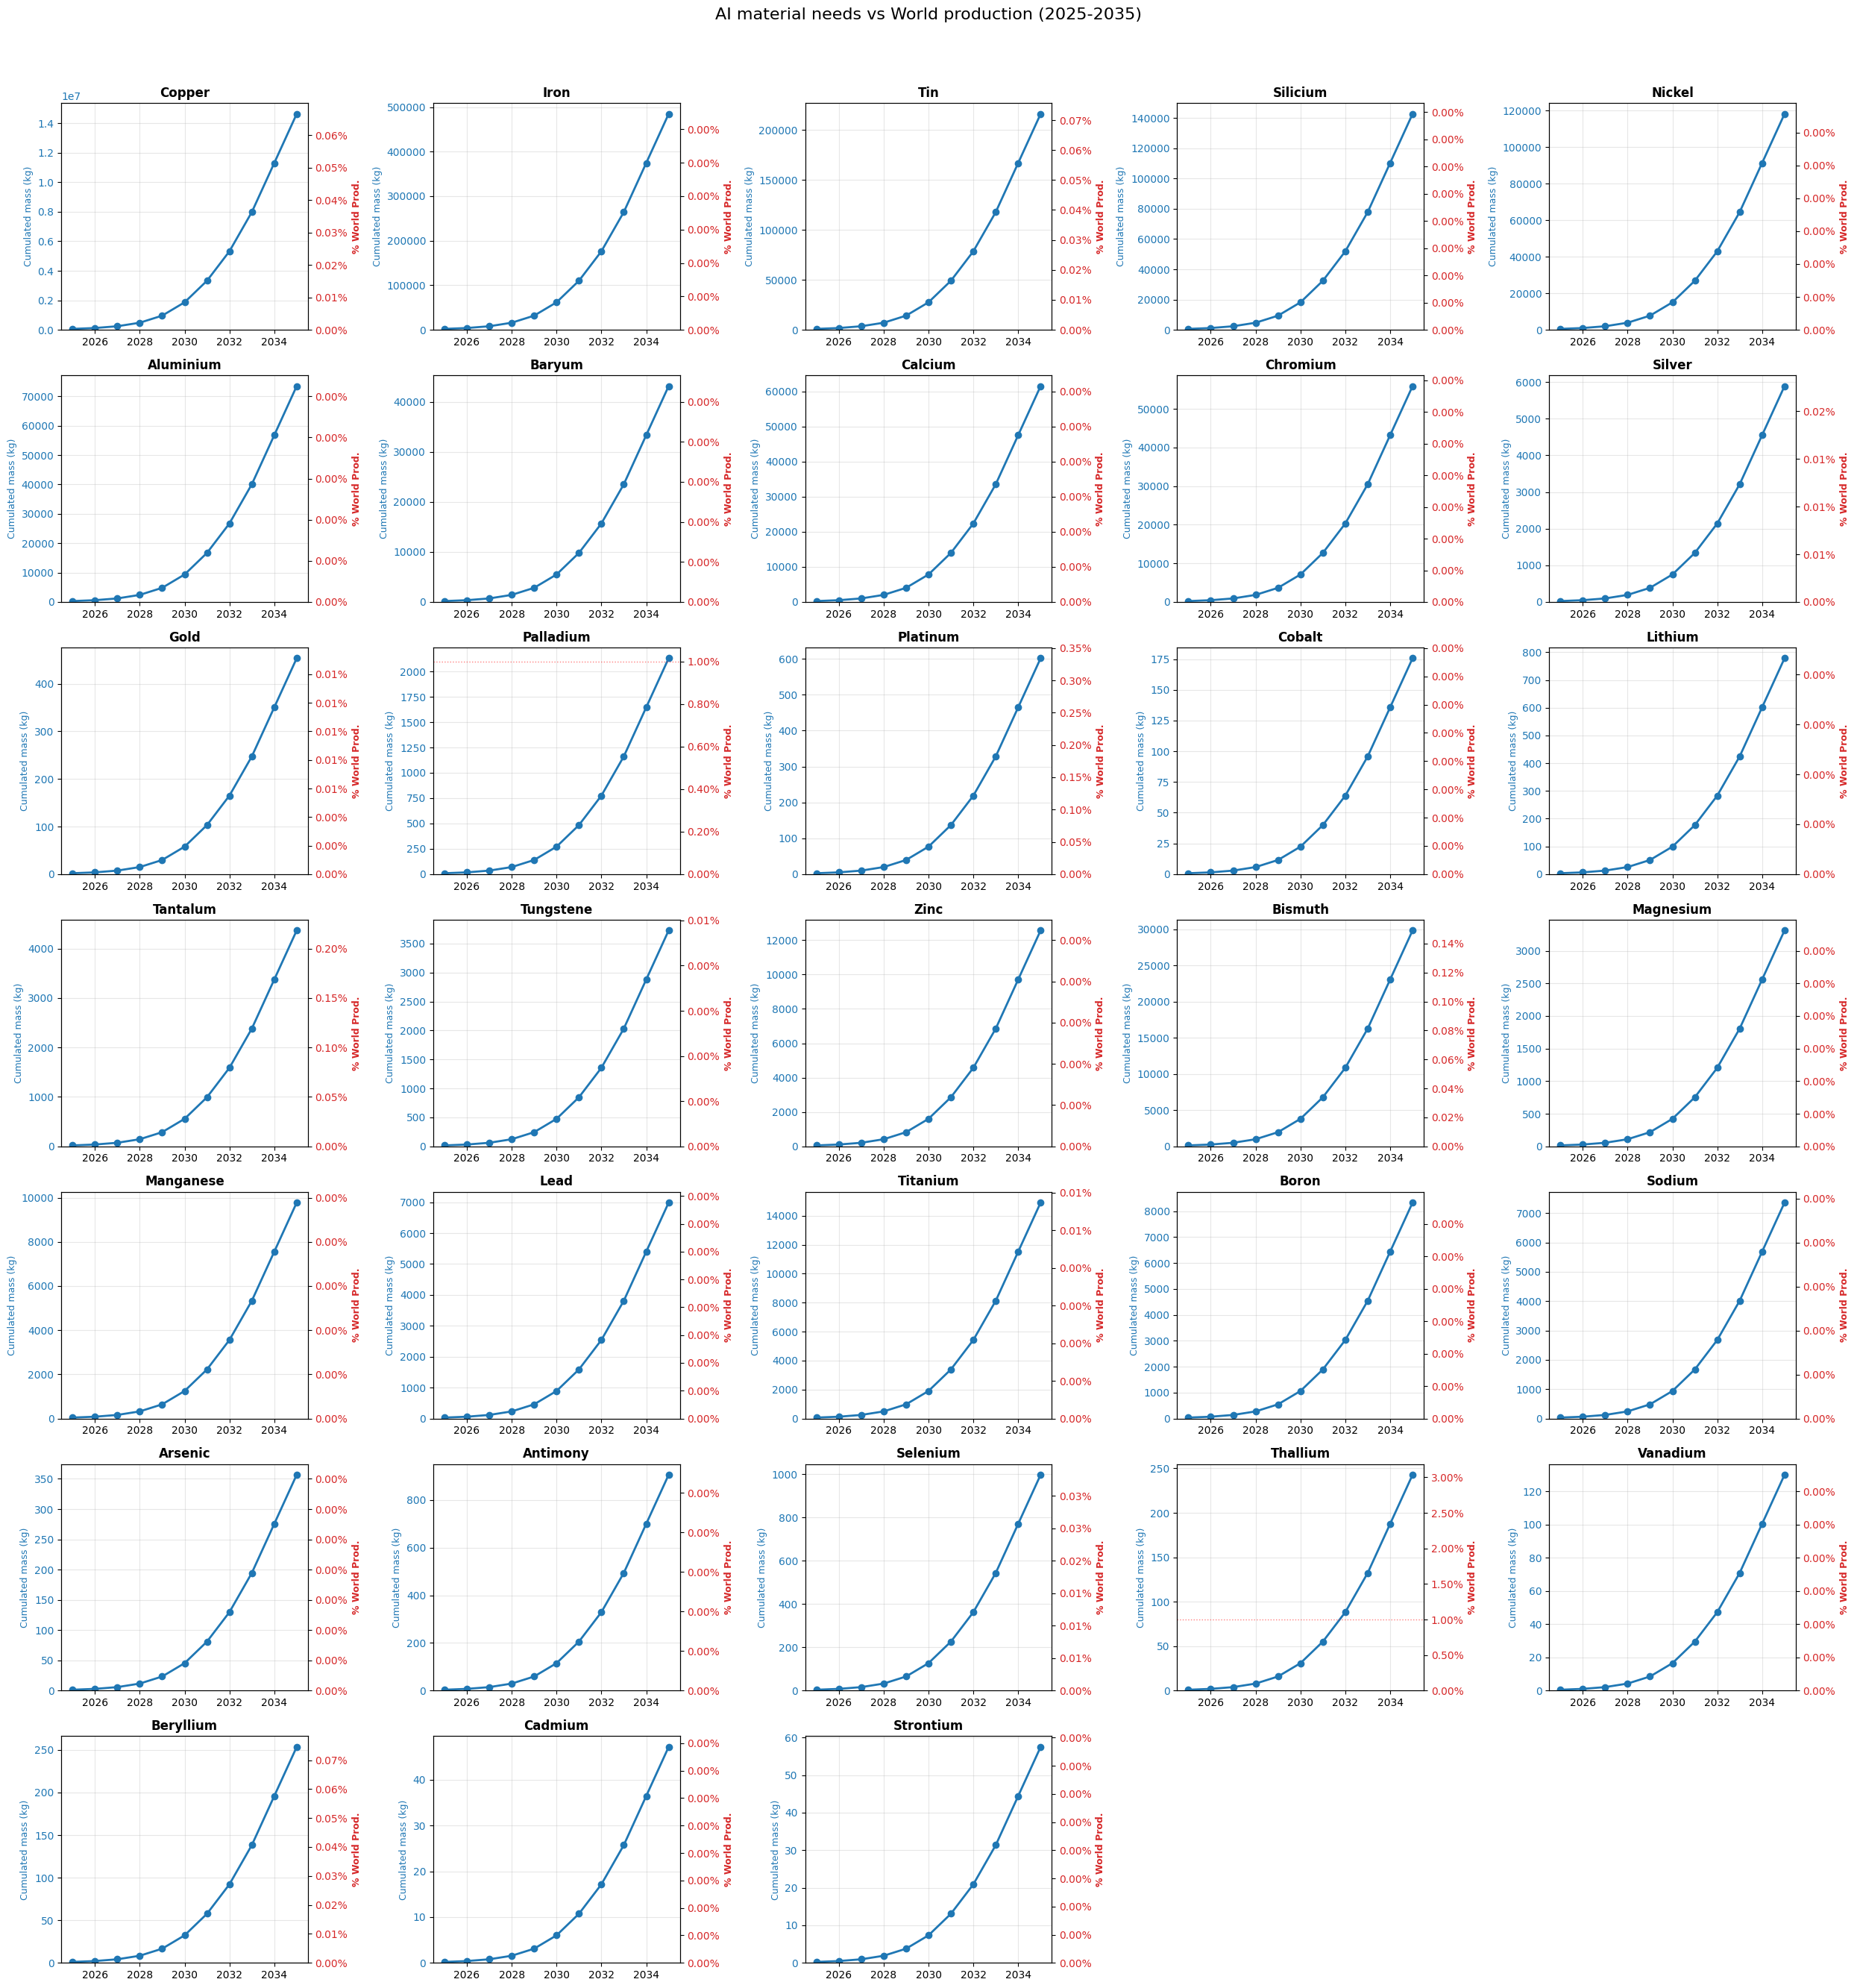

In [ ]:
visualize_impact([Projection_Perf_cons(n,C0,R) for n in range(11)], production_mondiale)

**Analyse de la pression matérielle induite par l’IA générative (2025–2035)**:

Les graphiques montrent une croissance fortement non linéaire de la demande en matériaux entre 2025 et 2035. Cette dynamique est principalement due à l’hypothèse d’une croissance rapide du nombre de requêtes adressées aux systèmes d’IA générative, qui domine largement l’effet de la durée de vie des GPU et de leur utilisation partielle. En conséquence, les gains d’efficacité technologique ne suffisent pas à compenser l’augmentation absolue des besoins matériels, ce qui conduit à une expansion rapide de la demande cumulée en ressources physiques.

Même si les parts relatives de la production mondiale mobilisées par l’IA restent quantitativement modestes, la dynamique observée révèle l’émergence d’une pression structurelle nouvelle sur certaines chaînes d’approvisionnement. Cette pression est particulièrement marquée pour les matériaux caractérisés soit par une forte concentration géographique de leur production, soit par une fonction technologique critique, pour lesquels la substituabilité est faible ou inexistante à court terme.

**Risques géopolitiques liés à la concentration géographique des ressources:**

La demande cumulée en palladium associée au fonctionnement des GPU atteindrait environ 1,00 % de la production mondiale annuelle à l’horizon 2035. Pour un métal dont l’extraction est principalement concentrée en Russie (environ 40 à 45 %) et en Afrique du Sud (35 à 40 %), avec des contributions plus marginales du Canada, des États-Unis, Zimbabwe et d’autres pays [3], la captation d’une telle part de marché par une seule filière technologique constitue un signal de tension critique. Cette concentration géographique accroît le risque de dépendance stratégique et expose la chaîne d’approvisionnement à des chocs exogènes, tels que des restrictions à l’exportation, des mesures protectionnistes ou l’instrumentalisation diplomatique des ressources minières.

Le platine présente un profil de risque comparable, bien que la part de la production mondiale mobilisée soit plus faible, estimée à environ 0,35 % en 2035. Ce métal est toutefois encore plus concentré géographiquement, l’Afrique du Sud détenant près de 88 % des réserves mondiales. Cette situation place l’infrastructure matérielle de l’IA dans une position de dépendance accrue vis-à-vis de la stabilité politique, sociale et énergétique d’une zone géographique unique, renforçant la vulnérabilité systémique de l’approvisionnement en composants critiques.

**Criticité technologique et rigidité de la demande en métaux spécifiques:**

Au-delà de la concentration géographique, certains métaux présentent un niveau de risque élevé en raison de leur fonction technologique critique et de la faible substituabilité de leurs propriétés physiques. Des éléments tels que le tantale, indispensable à certaines fonctions électroniques des puces de calcul avancées, illustrent une demande fortement rigide à court terme, pour laquelle les alternatives technologiques sont limitées ou inexistantes.

Par ailleurs, le cas du thallium met en évidence les vulnérabilités potentielles associées à l’intégration de métaux ultra-spécialisés à très faible production mondiale dans des architectures de calcul avancées. Dans un scénario où de tels éléments seraient mobilisés à plus grande échelle par l’IA générative, la demande cumulée pourrait représenter plus de 3,00 % de la production mondiale annuelle à l’horizon 2035. Une telle proportion, combinée à la rigidité de l’offre et à la concentration de la production, créerait une vulnérabilité accrue de la chaîne d’approvisionnement. Bien que le thallium ne constitue pas aujourd’hui un matériau critique des GPU, cet exemple illustre comment l’intégration future de métaux de niche peut transformer une contrainte d’approvisionnement marginale en risque systémique potentiel.

**Résilience des chaînes d’approvisionnement pour les métaux de base:**

À l’inverse, l’infrastructure matérielle des GPU repose majoritairement sur des métaux de base tels que le cuivre, le fer, le silicium, l’aluminium et le nickel, qui assurent les fonctions structurelles, électriques et thermiques fondamentales des unités de calcul. Bien que ces matériaux constituent l’essentiel de la masse physique d’un GPU, leur demande cumulée induite par l’IA générative reste marginale à l’échelle de la production mondiale.

À l’horizon 2035, cette demande ne représenterait qu’environ 0,07 % de la production mondiale de cuivre, une proportion comparable s’appliquant aux autres métaux de base. Compte tenu de leur abondance relative et de leur large répartition géographique, ces matériaux ne génèrent pas de tension significative sur la disponibilité globale, et ne constituent pas, en l’état, un facteur limitant pour le déploiement des infrastructures d’IA.

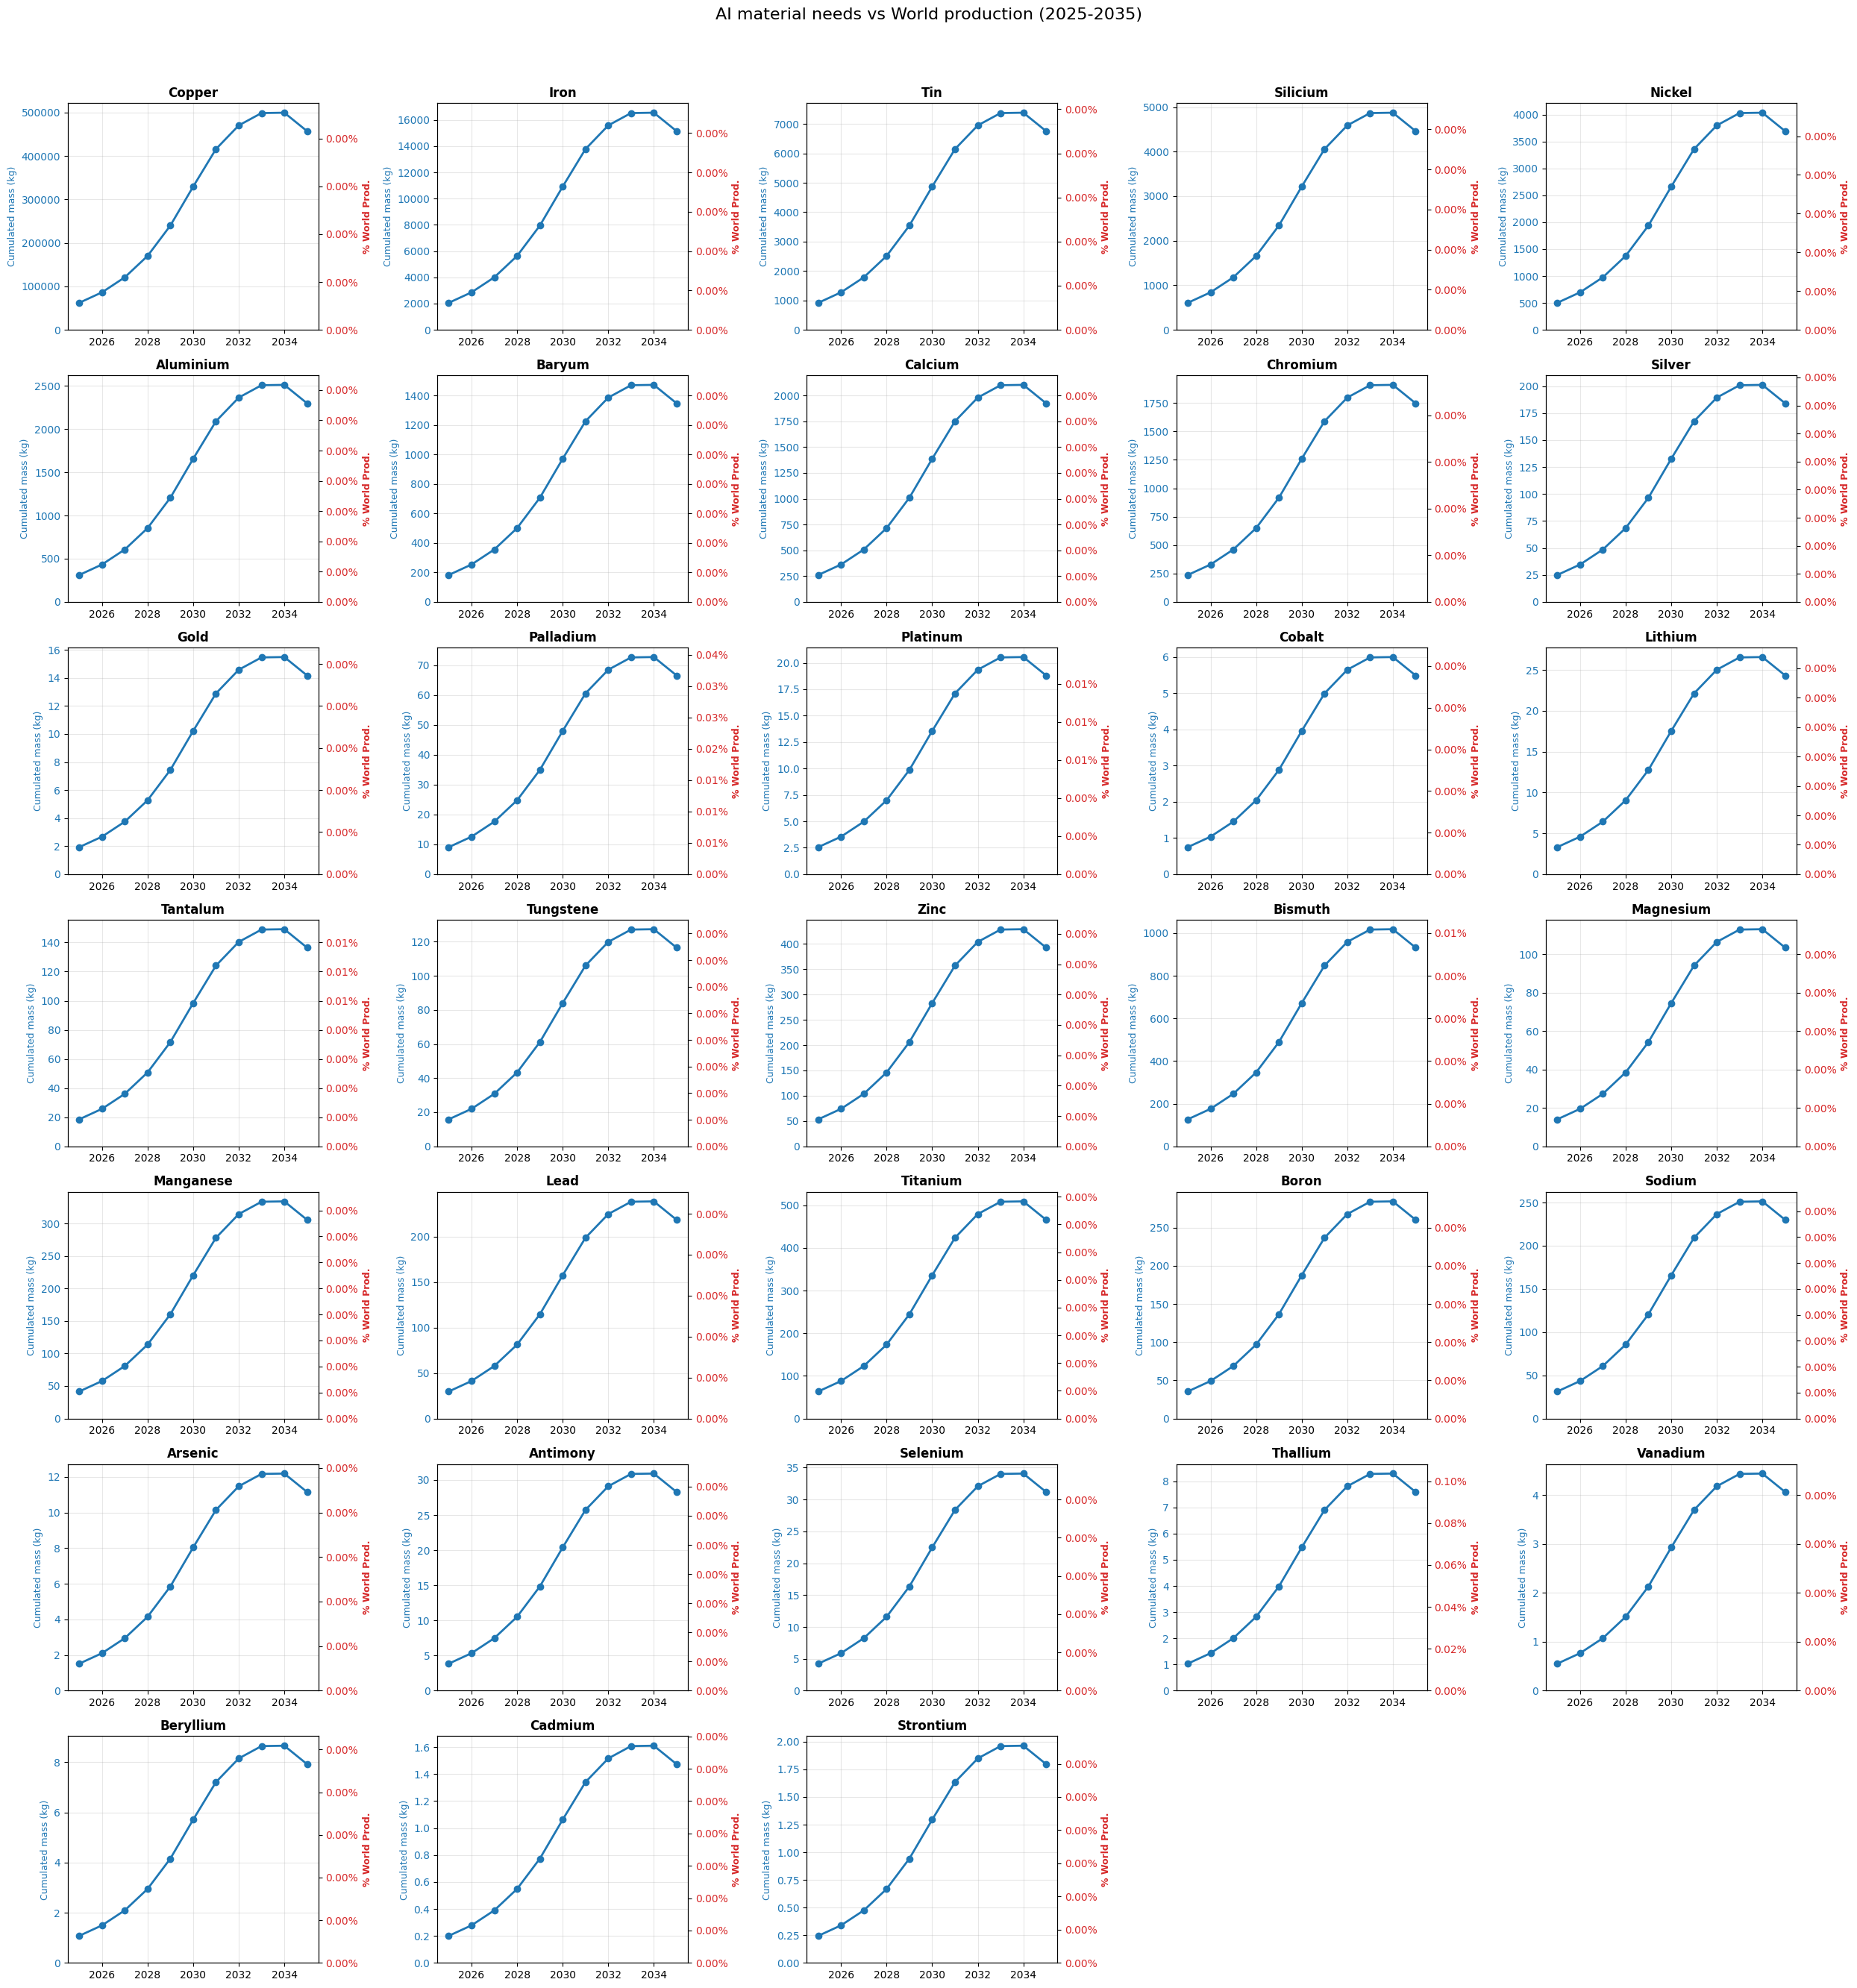

In [ ]:
visualize_impact([Projection_Perf_Realiste(n,C0,R) for n in range(0,11)], production_mondiale)

Le second modèle se distingue du premier par l’intégration d’une évolution temporelle de la performance des puces. Contrairement au scénario statique, la demande en matériaux n’est plus directement proportionnelle à la croissance du nombre de requêtes. L’amélioration continue de l’efficacité des GPU modifie la trajectoire des besoins matériels et permet d’analyser l’impact réel de l’innovation technologique sur la consommation de ressources physiques.

**Transformation des trajectoires de demande et point d’inflexion technologique:**

L’intégration des gains de performance entraîne une modification significative de la forme des courbes de demande pour les métaux. Après une phase de croissance rapide, ces trajectoires montrent une stabilisation progressive, suivie d’une légère inflexion à partir de 2033.

Ce point d’inflexion correspond au moment où les gains d’efficacité par unité de calcul deviennent suffisants pour compenser l’augmentation du volume global de requêtes. L’innovation technologique agit alors comme un mécanisme de découplage partiel entre la croissance de l’usage de l’IA et la mobilisation de ressources matérielles.

**Limites de l’optimisation : persistance des dépendances aux métaux critiques:**

Si l’innovation permet d’atténuer la pression sur les matériaux abondants, elle ne supprime pas les vulnérabilités structurelles associées aux métaux critiques. L’analyse montre que la réduction des volumes consommés ne remet pas en cause la dépendance fonctionnelle de l’architecture des GPU à certains éléments irremplaçables.

Ainsi, bien que le pic de consommation soit fortement réduit — par exemple, la part du thallium passant d’environ 3 % à 0,10 % de la production mondiale — la criticité demeure inchangée. Une rupture d’approvisionnement, même sur des quantités marginales, est susceptible de bloquer l’ensemble de la chaîne de production. Les verrous géopolitiques liés à la concentration géographique de ces ressources persistent donc pleinement.

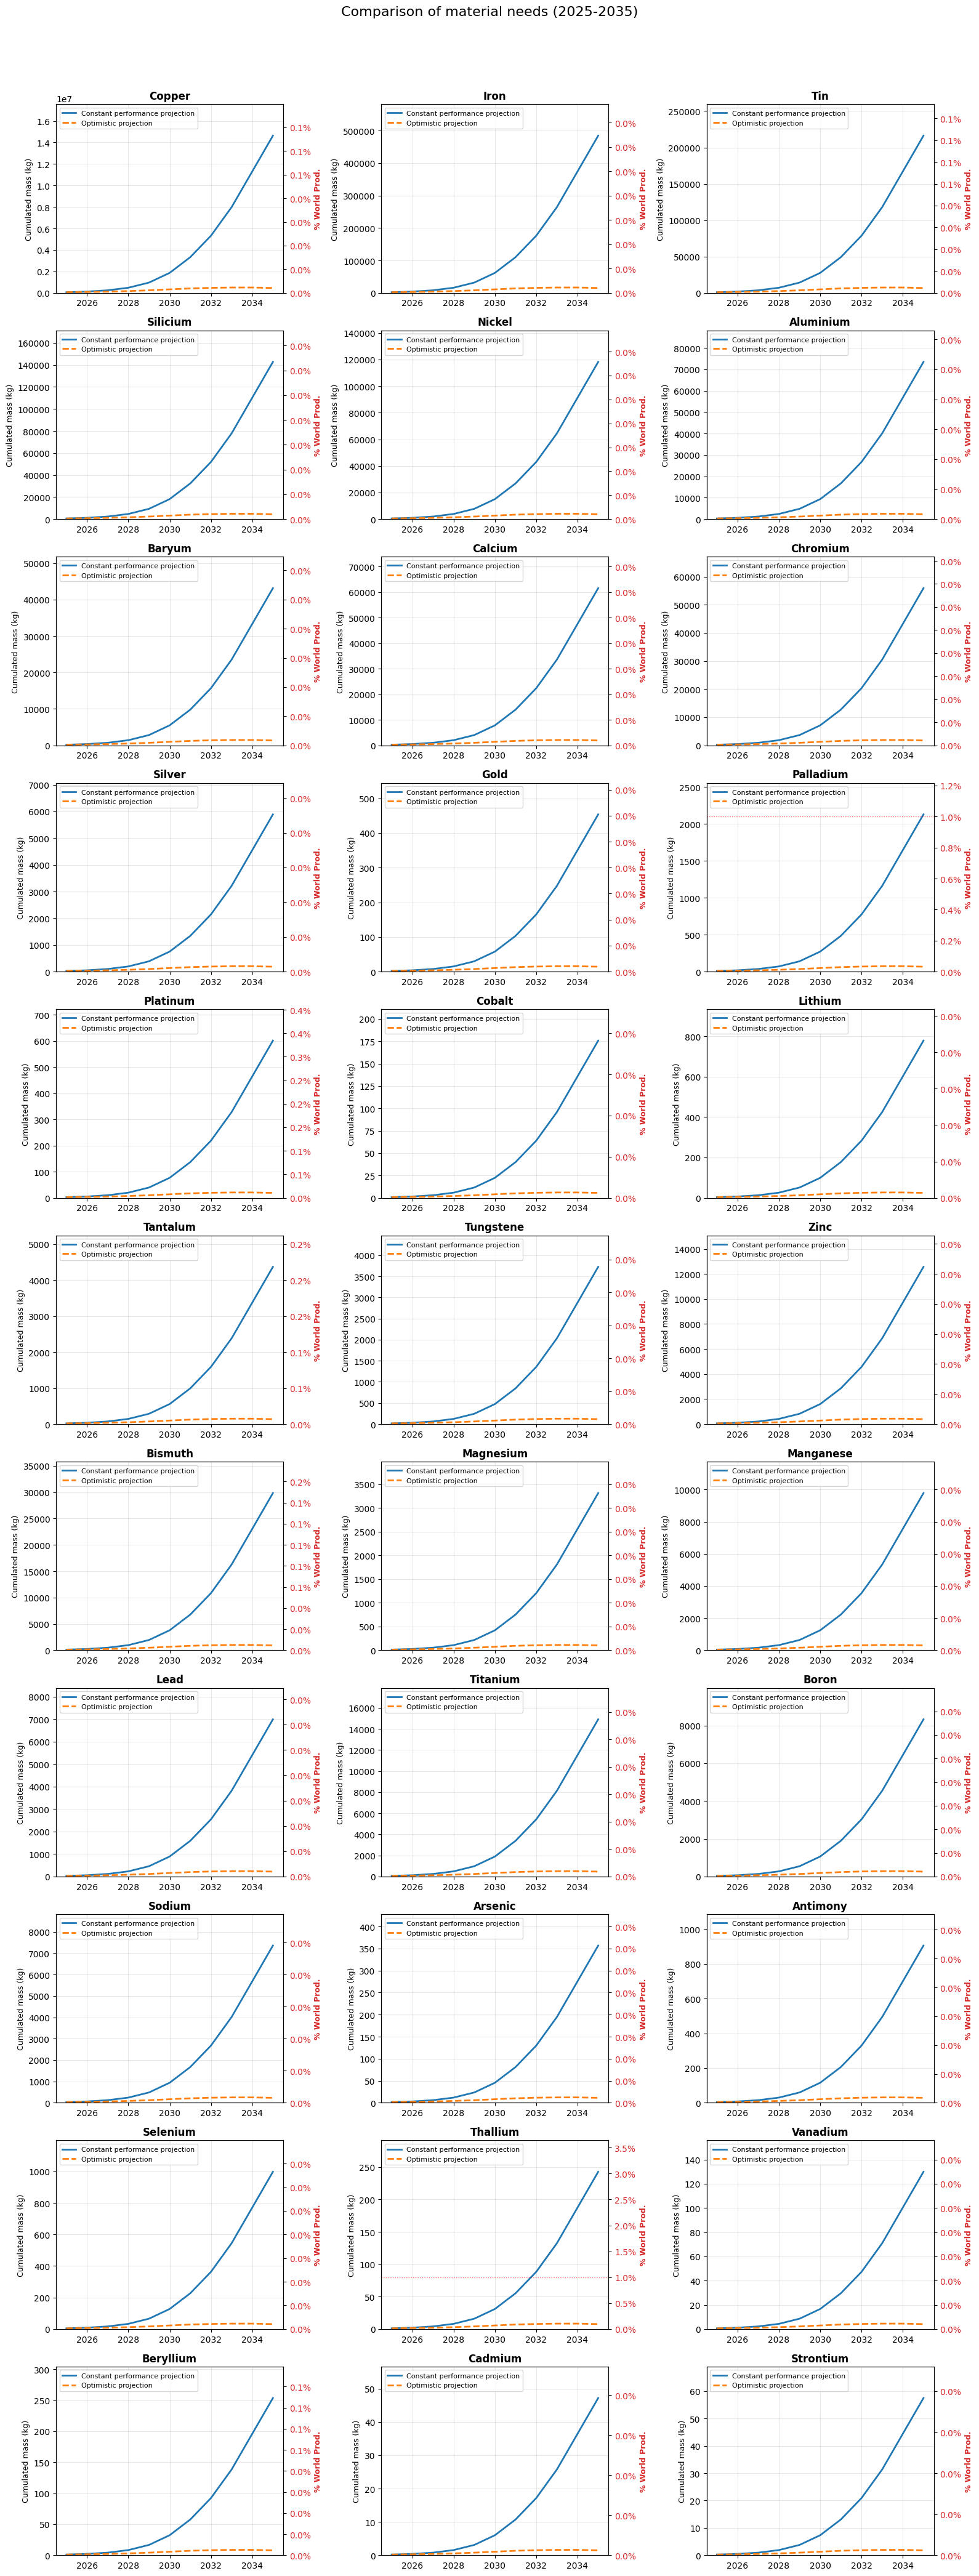

In [ ]:
visualize_impact_comparison([Projection_Perf_cons(n,C0,R) for n in range(11)],[Projection_Perf_Realiste(n,C0,R) for n in range(0,11)], production_mondiale)

La comparaison entre les deux scénarios met en évidence le rôle central de l’innovation technologique dans la gestion de la demande en matériaux. Alors que le scénario à performance constante traduit une augmentation continue et rapide de la consommation proportionnelle au volume de requêtes, le scénario réaliste montre que les gains d’efficacité des GPU permettent de traiter davantage de requêtes avec moins de ressources par unité de calcul. Cette évolution souligne l’importance de la performance matérielle dans la planification des besoins futurs et illustre comment l’optimisation technologique peut contribuer à réduire la pression sur les chaînes d’approvisionnement globales. Cependant, même avec ces gains, la criticité des métaux stratégiques demeure, et certaines dépendances structurelles subsistent.

## Prédiction du nombre de requêtes

# Annexe

## Troisième modèle - Composition variable, performance constante



On applique un taux de variation annuel alpha spécifique à chaque matériau.

Hypothèse : Les techniques de fabrication s'affinent. On utilise moins de matériaux structurels (plastique, aluminium) mais plus de matériaux technologiques.

$M_i(n) = M_{i0} * (1 + \alpha_i)^n$

Les hypothèses  

*   $\alpha_{Si}$ (+3% / an) : Augmente car les puces deviennent plus grandes et utilisent des technologies d'empilement (3D stacking, HBM) qui consomment beaucoup de surface de silicium
*   $\alpha_{Cu}$ (+1% / an) : Augmente légèrement pour les besoins de refroidissement (chambres à vapeur) et la densité du câblage électrique
*   $\alpha_{Al}$ (-1% / an) : Diminue légèrement, remplacé par des matériaux plus denses ou optimisé pour réduire l'encombrement.
*   PCB (0% / an) : Reste stable. La complexité augmente (plus de couches) mais la surface reste standardisée.


*   $\alpha_{Ta}$ (-2% / an): Tentative de réduction (éthique/coût)
*   $\alpha_{Pd}$ (-1% / an) : Tentative de réduction
*   $\alpha_{Au}$ (-2% / an) : Remplacement par cuivre/alliages si possible
*   $\alpha_{In}$ (+2% / an) : AUGMENTE : Plus de chauffe = plus de soudure Indium
*   $\alpha_{terre rare}$ (+0% / an)  # Stable


In [ ]:
# Composition hypothétique d'un GPU en 2025 (kg)
gpu_2025 = {
    # -- Matériaux de structure (Masse importante) --
    "silicium_kg": 0.05644,
    "cuivre_kg": 0.416,
    "alu_kg": 0.811,
    "pcb_kg": 0.3,
    "cobalt_kg" : 0.0145,

    # -- Matériaux Critiques (Masse faible mais stratégique) --
    "tantale_kg": 0.00041,
    "palladium_kg": 0.00034,
    "or_kg": 0.00067,
    "indium_kg": 0.003,
    "tungstene_kg" : 0.00035,
    "argent_kg" : 0.00239,
    "antimoine_kg" : 0.00227,
    "gallium_kg" : 0.00001,
    "germanium_kg" : 0.00008,
    "nickel_kg" : 0.00618,
    "platine_kg" : 0.00003
    }
alphas_2025 = {
        "silicium_kg": 0.03,  # +3%
        "cuivre_kg":   0.01,  # +1%
        "alu_kg":     -0.01,  # -1%
        "pcb_kg":      0.00,  #  0%

        # Évolution des critiques
        "tantale_kg": -0.02,    # Tentative de réduction (éthique/coût)
        "palladium_kg": -0.01,  # Tentative de réduction
        "or_kg": -0.02,         # Remplacement par cuivre/alliages si possible
        "indium_kg": 0.02,      # AUGMENTE : Plus de chauffe = plus de soudure Indium
        "terres_rares_kg": 0.0  # Stable
    }

In [ ]:
# Fonction renvoyant pour une année n, le vecteur matériau correspondant

def get_material_vector_at_year_n(base_mat_vector, n, alphas):
    """
    Calcule la composition matérielle d'un GPU à l'année n.
    Modèle d'évolution à taux constant (Intérêts composés).
    """

    # Création du nouveau vecteur
    compo_mat_n = {}

    for material, mass in base_mat_vector.items():
        # On récupère l'alpha spécifique, sinon 0 par défaut
        rate = alphas.get(material, 0.0)

        # Formule : Masse_n = Masse_0 * (1 + alpha)^n
        new_mass = mass * ((1 + rate) ** n)
        compo_mat_n[material] = round(new_mass, 4) # Arrondi pour la lisibilité

    return compo_mat_n

In [ ]:
def Projection_3_annee_n(n, R, base_mat_vector,alpha,FLOPS_per_request,GPU_TFLOPS,utilization=0.7,peak_factor=1.0):
    """
    Coordonne le calcul pour l'année n en appelant les sous-fonctions.
    """

    # 1. Récupération du nombre de requêtes dans le dictionnaire R
    key = f"a_{n}"
    if key not in R:
        return f"Erreur : Année {key} introuvable dans R"

    N_req_annee_n = R[key]

    # 2. Appel de la fonction de composition (Évolution des matériaux)
    # On récupère le vecteur matériaux pour l'année n

    # 3. Appel de la fonction de calcul GPU (Performance constante)
    # On utilise ce vecteur matériaux mis à jour pour calculer les totaux
    n_gpu = compute_GPU_2(N_requests=N_req_annee_n,period_seconds=365*24*3600,FLOPS_per_request=FLOPS_per_request,GPU_TFLOPS=GPU_TFLOPS,utilization_rate=utilization,peak_factor=peak_factor)
    materiaux_totaux = {key : 0 for key in base_mat_vector.keys()}
    for key in base_mat_vector.keys():
        materiaux_totaux[key] += get_material_vector_at_year_n(base_mat_vector,n,alpha)[key]*n_gpu
    return {
        "annee": n,
        "n_gpu": n_gpu,
        "materiaux_totaux": materiaux_totaux
    }

In [ ]:
visualize_impact([Projection_3_annee_n(n,R,base_mat_vector=gpu_2025,alpha=alphas_2025,FLOPS_per_request=1e11,GPU_TFLOPS=1e12) for n in range(0,11)], production_mondiale_kg)

NameError: name 'compute_GPU_2' is not defined

On prédit le nombre de requête par machine learning à partir :
1) Du nombre d'utilisateurs ($N_u$) que l'on considère croissant exponentiellement pour l’instant d'après les données trouvées dans nos sources (pb : nb données faible car chatgpt récent donc prédiction peu fiable sur de longues durées mais peut donner une estimation haute).
2) Du nombre de requêtes ($n_r$) journalier par utilisateur aussi croissant à estimer également par régression.

Nombre de requête/an : $N_R = N_u*n_r*365$


In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
import matplotlib.pyplot as plt


T = np.array([2023+0.5*n for n in range(7)]).reshape(-1,1)
Nu = np.array([1e6,60e6, 90e6, 120e6, 230e6, 420e6, 770e6])
obj = 2.4e9 #objectif 2035
poly = PolynomialFeatures(degree=2)
T_poly = poly.fit_transform(T)

reg = LinearRegression().fit(
    np.concatenate((T_poly, poly.fit_transform(np.array(2035).reshape(-1, 1))))
    ,
    np.concatenate((Nu, np.array([obj])))
)

fig, ax = plt.subplots(figsize=(10,6))
ax.plot(T,Nu,'o',label='valeurs réelles')
ax.plot(2035,obj,'o',label="objectif 2035")

plot_years = 2023 + np.linspace(0, 13, 1000).reshape(-1, 1)
ax.plot(plot_years, reg.predict(poly.fit_transform(plot_years)), label=f'régression (score = {reg.score(T_poly, Nu):.2f})')

#ax.set_yscale('log')
ax.set_xlabel('année')
ax.set_ylabel("nombre d'utilisateurs")
ax.legend()
ax.grid(True)
plt.show()

In [ ]:
T = np.array([2023+(7+n)/12 for n in range(26)]).reshape(-1,1)
Nr = np.array([1.00, 0.92, 0.87, 0.94, 0.93, 0.85,
 0.76, 0.77, 0.78, 0.79, 0.80, 0.81,
 0.81, 0.82, 0.85, 0.95, 1.02, 1.05,
 1.04, 1.08, 1.12, 1.22, 1.32, 1.38,
 1.41, 1.42])
obj = 5
poly1 = PolynomialFeatures(degree=2)
T_poly = poly1.fit_transform(T)
reg1 = LinearRegression().fit(
    np.concatenate((T_poly, poly1.fit_transform(np.array(2035).reshape(-1, 1))))
    ,
    np.concatenate((Nr, np.array([obj])))
)
fig,ax = plt.subplots(figsize=(10,6))
ax.plot(T,Nr,'o',label='valeurs réelles')
ax.plot(2035,obj,'o',label="objectif 2035")
ax.plot(2023+np.linspace(0.5,12,1000),reg1.predict(poly1.fit_transform(2023+np.linspace(0.5,12,1000).reshape(-1,1))),label= f'régression (score = {reg1.score(T_poly,Nr)})')
ax.set_xlabel('année')
ax.set_ylabel("nombre de requêtes par jour et par personne")
ax.legend()
ax.grid(True)
plt.show()

In [ ]:
T1 = np.array([2022+n for n in range(3,14)])
N_R = np.array(reg.predict(poly.fit_transform(T1.reshape(-1,1))))*np.array(reg1.predict(poly1.fit_transform(T1.reshape(-1,1))))*365
print(N_R)
plt.figure()
plt.plot(T1,N_R,'o')
plt.semilogy()
plt.grid(True)
plt.show()

# Analyse


## 1. Analyse de la criticité et éventuels conflits géopolitiques

*Photo graphe*

                                        [9]
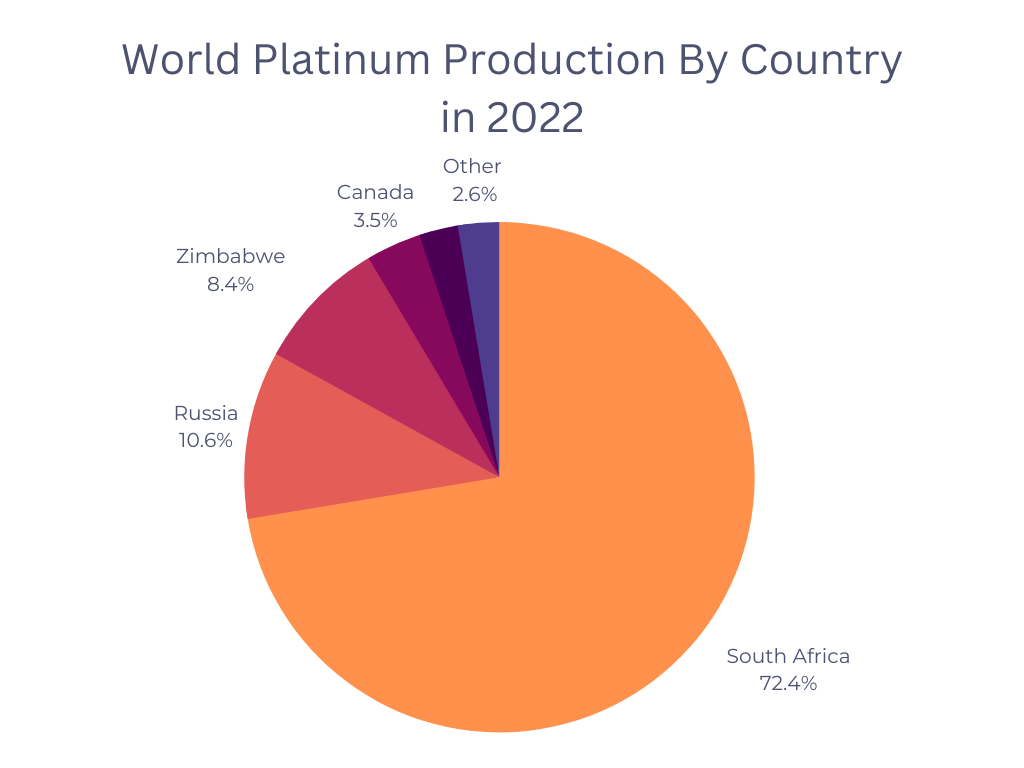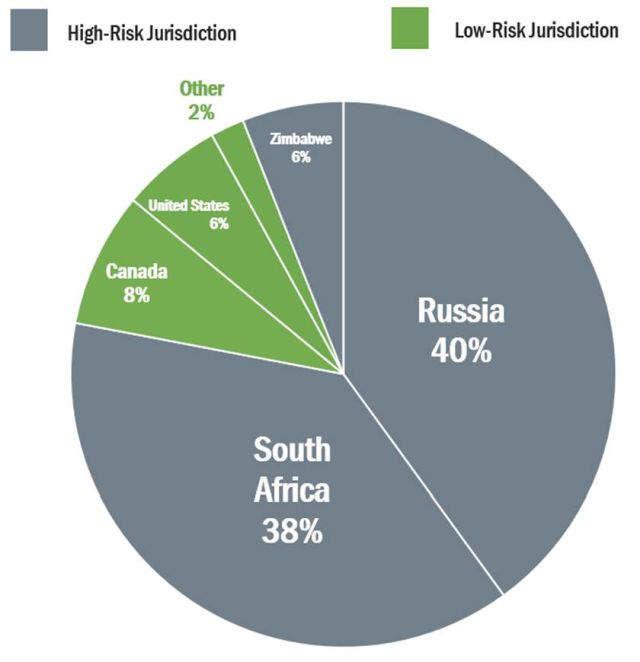

             Parts de production mondiale de platine par pays[10]

Analyse de la pression matérielle induite par l’IA générative (2025–2035):

Les graphiques montrent une croissance fortement non linéaire de la demande en matériaux entre 2025 et 2035. Cette dynamique est principalement due à l’hypothèse d’une croissance rapide du nombre de requêtes adressées aux systèmes d’IA générative, qui domine largement l’effet de la durée de vie des GPU et de leur utilisation partielle. En conséquence, les gains d’efficacité technologique ne suffisent pas à compenser l’augmentation absolue des besoins matériels, ce qui conduit à une expansion rapide de la demande cumulée en ressources physiques.

Même si les parts relatives de la production mondiale mobilisées par l’IA restent quantitativement modestes, la dynamique observée révèle l’émergence d’une pression structurelle nouvelle sur certaines chaînes d’approvisionnement. Cette pression est particulièrement marquée pour les matériaux caractérisés soit par une forte concentration géographique de leur production, soit par une fonction technologique critique, pour lesquels la substituabilité est faible ou inexistante à court terme.

Risques géopolitiques liés à la concentration géographique des ressources:

La demande cumulée en palladium associée au fonctionnement des GPU atteindrait environ 1,00 % de la production mondiale annuelle à l’horizon 2035. Pour un métal dont l’extraction est principalement concentrée en Russie (environ 40 à 45 %) et en Afrique du Sud (35 à 40 %), avec des contributions plus marginales du Canada, des États-Unis, Zimbabwe et d’autres pays [3], la captation d’une telle part de marché par une seule filière technologique constitue un signal de tension critique. Cette concentration géographique accroît le risque de dépendance stratégique et expose la chaîne d’approvisionnement à des chocs exogènes, tels que des restrictions à l’exportation, des mesures protectionnistes ou l’instrumentalisation diplomatique des ressources minières.

Le platine présente un profil de risque comparable, bien que la part de la production mondiale mobilisée soit plus faible, estimée à environ 0,35 % en 2035. Ce métal est toutefois encore plus concentré géographiquement, l’Afrique du Sud détenant près de 88 % des réserves mondiales. Cette situation place l’infrastructure matérielle de l’IA dans une position de dépendance accrue vis-à-vis de la stabilité politique, sociale et énergétique d’une zone géographique unique, renforçant la vulnérabilité systémique de l’approvisionnement en composants critiques.

Criticité technologique et rigidité de la demande en métaux spécifiques:

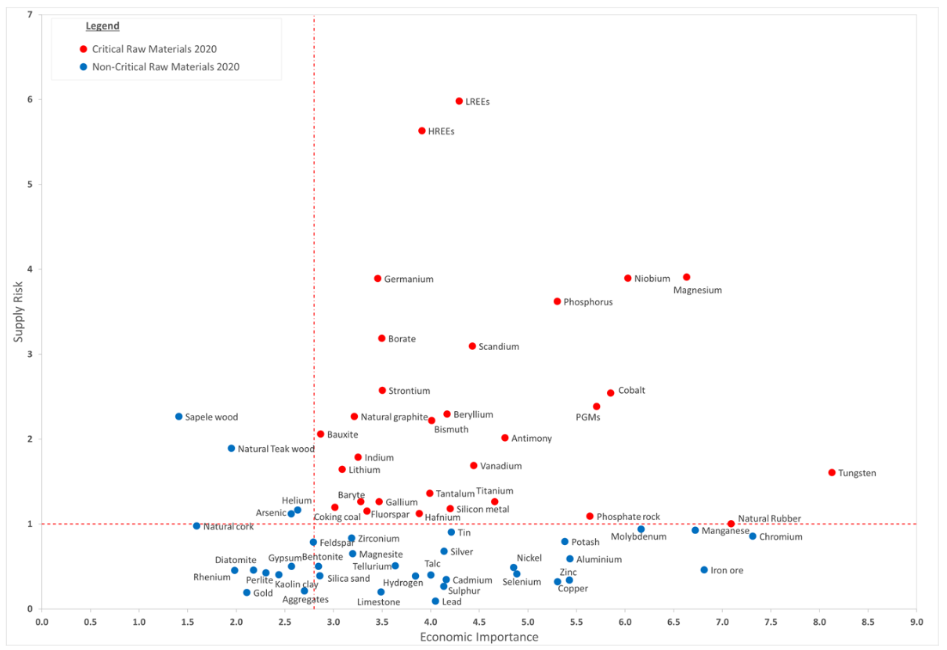

  Résultats de l’évaluation de la criticité 2020 : importance économique et risque d’approvisionnement [11]

Au-delà de la concentration géographique, certains métaux présentent un niveau de risque élevé en raison de leur fonction technologique critique et de la faible substituabilité de leurs propriétés physiques. Des éléments tels que le tantale, indispensable à certaines fonctions électroniques des puces de calcul avancées, illustrent une demande fortement rigide à court terme, pour laquelle les alternatives technologiques sont limitées ou inexistantes.

Par ailleurs, le cas du thallium met en évidence les vulnérabilités potentielles associées à l’intégration de métaux ultra-spécialisés à très faible production mondiale dans des architectures de calcul avancées. Dans un scénario où de tels éléments seraient mobilisés à plus grande échelle par l’IA générative, la demande cumulée pourrait représenter plus de 3,00 % de la production mondiale annuelle à l’horizon 2035. Une telle proportion, combinée à la rigidité de l’offre et à la concentration de la production, créerait une vulnérabilité accrue de la chaîne d’approvisionnement. Bien que le thallium ne constitue pas aujourd’hui un matériau critique des GPU, cet exemple illustre comment l’intégration future de métaux de niche peut transformer une contrainte d’approvisionnement marginale en risque systémique potentiel.

Résilience des chaînes d’approvisionnement pour les métaux de base:

À l’inverse, l’infrastructure matérielle des GPU repose majoritairement sur des métaux de base tels que le cuivre, le fer, le silicium, l’aluminium et le nickel, qui assurent les fonctions structurelles, électriques et thermiques fondamentales des unités de calcul. Bien que ces matériaux constituent l’essentiel de la masse physique d’un GPU, leur demande cumulée induite par l’IA générative reste marginale à l’échelle de la production mondiale.

À l’horizon 2035, cette demande ne représenterait qu’environ 0,07 % de la production mondiale de cuivre, une proportion comparable s’appliquant aux autres métaux de base. Compte tenu de leur abondance relative et de leur large répartition géographique, ces matériaux ne génèrent pas de tension significative sur la disponibilité globale, et ne constituent pas, en l’état, un facteur limitant pour le déploiement des infrastructures d’IA.

*Photo graphe*

Le second modèle se distingue du premier par l’intégration d’une évolution temporelle de la performance des puces. Contrairement au scénario statique, la demande en matériaux n’est plus directement proportionnelle à la croissance du nombre de requêtes. L’amélioration continue de l’efficacité des GPU modifie la trajectoire des besoins matériels et permet d’analyser l’impact réel de l’innovation technologique sur la consommation de ressources physiques.

Transformation des trajectoires de demande et point d’inflexion technologique:

L’intégration des gains de performance entraîne une modification significative de la forme des courbes de demande pour les métaux de base et de structure (cuivre, silicium, étain). Après une phase de croissance rapide, ces trajectoires montrent une stabilisation progressive, suivie d’une légère inflexion à partir de 2033.

Ce point d’inflexion correspond au moment où les gains d’efficacité par unité de calcul deviennent suffisants pour compenser l’augmentation du volume global de requêtes. L’innovation technologique agit alors comme un mécanisme de découplage partiel entre la croissance de l’usage de l’IA et la mobilisation de ressources matérielles.

Limites de l’optimisation : persistance des dépendances aux métaux critiques:

Si l’innovation permet d’atténuer la pression sur les matériaux abondants, elle ne supprime pas les vulnérabilités structurelles associées aux métaux critiques. L’analyse montre que la réduction des volumes consommés ne remet pas en cause la dépendance fonctionnelle de l’architecture des GPU à certains éléments irremplaçables.

Ainsi, bien que le pic de consommation soit fortement réduit. Une rupture d’approvisionnement, même sur des quantités marginales, est susceptible de bloquer l’ensemble de la chaîne de production. Les verrous géopolitiques liés à la concentration géographique de ces ressources persistent donc pleinement.

*Photos graphes*

La comparaison entre les deux scénarios met en évidence le rôle central de l’innovation technologique dans la gestion de la demande en matériaux. Alors que le scénario à performance constante traduit une augmentation continue et rapide de la consommation proportionnelle au volume de requêtes, le scénario réaliste montre que les gains d’efficacité des GPU permettent de traiter davantage de requêtes avec moins de ressources par unité de calcul. Cette évolution souligne l’importance de la performance matérielle dans la planification des besoins futurs et illustre comment l’optimisation technologique peut contribuer à réduire la pression sur les chaînes d’approvisionnement globales. Cependant, même avec ces gains, la criticité des métaux stratégiques demeure, et certaines dépendances structurelles subsistent.

##  2. Conséquences environnementales

Beyond the quantitative pressure on resources, analysis of the material composition of GPUs reveals a critical qualitative dimension: the prevalence of toxic materials. Contrary to the perception of “immaterial” technology, the physical infrastructure required for generative AI to function is extensive and environmentally risky.

*Predominance of toxic metals in GPU chips*
The reference chip in our study is composed of 93% toxic or hazardous materials. These primarily include heavy metals which, while present in small or trace amounts, are highly harmful. This includes elements such as Arsenic, Mercury, Cadmium, Chromium, Nickel, Antimony, Cobalt, and Beryllium.



*Health and ecological risks*
According to [ World Health Organization. World health statistics 2010. World Health Organization, 2010 ] The extraction and final disposal of these components generate acute risks for natural environments, ecosystems, and human health. These toxic metals pose significant hazards if released during mining, manufacturing, or at the end of their operational life. Some are classified as carcinogenic or neurotoxic. Exposure to these elements, whether through inhalation of dust, skin contact, or ingestion of contaminated water, is associated with serious diseases (lung cancer, neurological disorders, gastrointestinal disorders). Lead, for example, is dangerous even in minute concentrations (parts per billion).

Furthermore, in many mining regions, particularly in sub-Saharan Africa (according to [Asha Ripanda et al. ‘Combatting toxic chemical elements pollution for Sub-Saharan Africa’s ecological health’. In:
Environmental Pollution and Management (2025)] and  [N. Wang et al. ‘Analysis of soil fertility and toxic metal characteristics in open-pit mining areas in northern Shaanxi’. In:
Sci. Rep. 14.1 (2024), p. 2273. DOI: 10.1038/s41598-024-52886-8] ), concentrations of toxic metals in soil and water far exceed WHO drinking water standards. The AI industry, through its growing demand, is increasing this pollution in areas where environmental governance is often limited and risk mitigation capabilities are weak.


To quantify this pollution, it is possible to put a figure on this phenomenon. Let's focus, for example, on the pollution generated by training an AI such as ChatGPT 4.

As explained in the first part, we assume 222 billion active parameters ($N^*$) and a training dataset of 13 trillion tokens ($D$). The A100 chip has a theoretical peak throughput of 312 TFLOPS (BF16 precision).

Training Computational Budget

$$\text{Budget} = 6 \times (222 \times 10^9) \times (13 \times 10^{12}) \approx 1.73 \times 10^{25} \text{ FLOPs}$$

Effective Annual GPU Throughput

$$\text{Effective Capacity} = (312 \times 10^{12}) \times (365 \times 24 \times 3600) \times 0.35 \approx 3.44 \times 10^{21} \text{ FLOPs}$$

Number of chips required

$$\text{GPU Count} = \frac{1.73 \times 10^{25}}{3.44 \times 10^{21}} \approx 5,029 \text{ GPUs}$$

The mass of one chip is about 1,6 kg and contains around 90% of toxic materials, which accounts for around 1,4 kg.

$$\text{Total Toxic Mass} = 5,029 \text{ GPUs} \times 1.4 \text{ kg/GPU} \approx 7,000 \text{ kg}$$

A chat gpt 4 training session releases around 7 tons of highly toxic materials.

## 3. Limites du modèle

Bien que ce modèle offre une première approche pour évaluer la demande en matériaux de l'IA générative, il présente plusieurs limites importantes. Premièrement, la prévision du nombre de requêtes est intrinsèquement incertaine. Les données historiques disponibles sont limitées, notamment pour des technologies récentes comme ChatGPT, ce qui rend les projections sur le long terme (ici 10 ans) sujettes à de grandes variations et à une fiabilité discutable. De plus, le modèle actuel n'intègre pas la variation de la composition des GPU au fil du temps, se basant sur une composition statique de la puce A100. En réalité, les technologies évoluent rapidement, et les puces futures pourraient utiliser des matériaux différents, ou des quantités variables des mêmes matériaux, sous l'effet de l'innovation, des contraintes d'approvisionnement ou des préoccupations environnementales. Par exemple, l'hypothèse de l'évolution de la performance des GPU (Loi de Moore) est appliquée à l'échelle de la puce, mais la masse totale et la composition matérielle de celle-ci sont supposées constantes. Une analyse plus fine devrait considérer comment les gains de performance sont liés à des changements physiques (ex: plus de silicium, de cuivre pour le refroidissement, etc.) plutôt qu'à une simple amélioration technologique 'immatérielle'. Ces facteurs pourraient significativement influencer la demande cumulée en matériaux et la pression sur les ressources mondiales.

## Conclusion

Cette étude a mis en évidence l'impact matériel significatif de l'IA générative, en se concentrant sur les besoins en matériaux pour les GPU. Les scénarios de croissance des requêtes et d'évolution des performances technologiques révèlent une demande croissante, bien que les gains d'efficacité puissent atténuer une partie de cette pression. Cependant, la dépendance à des matériaux critiques, souvent concentrés géopolitiquement, soulève des vulnérabilités importantes pour la chaîne d'approvisionnement. Au-delà des volumes, la prédominance de matériaux toxiques dans la composition des GPU pose des défis environnementaux et sanitaires majeurs, notamment lors de l'extraction et de l'élimination. Les limites de ce modèle, notamment l'incertitude des prévisions de requêtes et la simplification des processus de formation et de la composition des GPU, soulignent la nécessité de recherches plus approfondies et de modèles plus complexes pour une compréhension exhaustive de l'empreinte matérielle de l'IA.